# Loading Responses

In [17]:
options(warn=2, error=recover)
install_if_missing <- function(pkg, github = NULL) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message(sprintf("Installing package: %s", pkg))
    tryCatch({
      if (is.null(github)) {
        install.packages(pkg, repos = "https://cloud.r-project.org")
      } else {
        if (!requireNamespace("remotes", quietly = TRUE)) {
          install.packages("remotes", repos = "https://cloud.r-project.org")
        }
        remotes::install_github(github)
      }
    }, error = function(e) {
      message(sprintf("Failed to install %s: %s", pkg, e$message))
      return(NULL)
    })
  }
  if (requireNamespace(pkg, quietly = TRUE)) {
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("Package %s is still not available after attempted installation.", pkg))
  }
}
pkgs <- c("lme4","readr","marginaleffects","ggplot2","dplyr","parameters", "performance")
lapply(pkgs, function(pkg){
  install_if_missing(pkg)
})
install_if_missing("ggeffects", "strengejacke/ggeffects")
sessionInfo()


Attaching package: ‘dplyr’


The following object is masked from ‘package:car’:

    recode


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[[1]]
 [1] "performance"     "parameters"      "ggplot2"         "car"            
 [5] "carData"         "marginaleffects" "readr"           "lme4"           
 [9] "Matrix"          "stats"           "graphics"        "grDevices"      
[13] "utils"           "datasets"        "methods"         "base"           

[[2]]
 [1] "performance"     "parameters"      "ggplot2"         "car"            
 [5] "carData"         "marginaleffects" "readr"           "lme4"           
 [9] "Matrix"          "stats"           "graphics"        "grDevices"      
[13] "utils"           "datasets"        "methods"         "base"           

[[3]]
 [1] "performance"     "parameters"      "ggplot2"         "car"            
 [5] "carData"         "marginaleffects" "readr"           "lme4"           
 [9] "Matrix"          "stats"           "graphics"        "grDevices"      
[13] "utils"           "datasets"        "methods"         "base"           

[[4]]
 [1] "performance"     "parameters"      "ggplot2"         "car"            
 [5] "carData"         "marginaleffects" "readr"           "lme4"           
 [9] "Matrix"          "stats"           "graphics"        "grDevices"      
[13] "utils"           "datasets"        "methods"         "base"           

[[5]]
 [1] "dplyr"           "performance"     "parameters"      "ggplot2"        
 [5] "car"             "carData"         "marginaleffects" "readr"          
 [9] "lme4"            "Matrix"          "stats"           "graphics"       
[13] "grDevices"       "utils"           "datasets"        "methods"        
[17] "base"           

[[6]]
 [1] "dplyr"           "performance"     "parameters"      "ggplot2"        
 [5] "car"             "carData"         "marginaleffects" "readr"          
 [9] "lme4"            "Matrix"          "stats"           "graphics"       
[13] "grDevices"       "utils"           "datasets"        "methods"        
[17] "base"           

[[7]]
 [1] "dplyr"           "performance"     "parameters"      "ggplot2"        
 [5] "car"             "carData"         "marginaleffects" "readr"          
 [9] "lme4"            "Matrix"          "stats"           "graphics"       
[13] "grDevices"       "utils"           "datasets"        "methods"        
[17] "base"

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 26.1

Matrix products: default
BLAS/LAPACK: /Users/zory/miniforge3/envs/py310/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C.UTF-8/C.UTF-8/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: America/New_York
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggeffects_2.3.2        dplyr_1.1.4            performance_0.14.0    
 [4] parameters_0.28.3      ggplot2_3.5.1          car_3.1-3             
 [7] carData_3.0-5          marginaleffects_0.25.1 readr_2.1.5           
[10] lme4_1.1-35.5          Matrix_1.6-5          

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       bayestestR_0.17.0  insight_1.4.4      lattice_0.22-6    
 [5] tzdb_0.5.0         vctrs_0.6.5        tools_4.3.3        Rdpack_2.6.4      
 [9] generics_0.1.4     datawizard_1.3.0   parallel_4.3.3   

In [ ]:
df <- read_csv("../output/result_1763865486_20250506_20250506T_20251123_20251124.csv", na = "empty", col_select = c("Accuracy", "Group", "GroupKind", "Angle", "Proximity", "n_candidates", "Actor", "Candidates", "Stimulus_ID", "Prompt_ID", "Participant_ID", "list_id", "Run_ID", "Part", "Accuracy_head", "Wrongness", "Wrongness_head", "Wrongness_max", "Wrongness_exp"), col_types = cols(
    Accuracy = col_logical(),
    Group = col_factor(),
    GroupKind = col_factor(),
    Angle = col_factor(),
    Proximity = col_integer(),
    n_candidates = col_integer(),
    Actor = col_factor(c('X', 'Y')),
    Candidates = col_factor(),
    Stimulus_ID = col_factor(),
    Prompt_ID = col_factor(),
    Participant_ID = col_factor(),
    list_id = col_factor(),
    Run_ID = col_character(),
    Part = col_character(),
    Accuracy_head = col_logical(),
    Wrongness = col_integer(),
    Wrongness_head = col_integer(),
    Wrongness_max = col_integer(),
    Wrongness_exp = col_double(),
),show_col_types = TRUE)
df <- df[df$Group == "Humans" & df$list_id != -1 & df$Part != "p0", ]
df$offset_logit <- qlogis(df$Wrongness_exp / df$Wrongness_max)
df$n_candidates_c <- as.numeric(scale(df$n_candidates, scale = FALSE))
df$Proximity_c    <- as.numeric(scale(df$Proximity, scale = FALSE))
strict_control <- glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 166693 Columns: 19
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Run_ID, Part
dbl (1): Wrongness_exp
int (5): Proximity, n_candidates, Wrongness, Wrongness_head, Wrongness_max
lgl (2): Accuracy, Accuracy_head
fct (9): Stimulus_ID, Prompt_ID, Participant_ID, Group, GroupKind, Angle, Ac...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Random effect structure

In [11]:
model1 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Participant_ID) + (1 | Actor:Candidates), data = df, family = binomial, control = strict_control)
model2 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Actor:Candidates), data = df, family = binomial, control = strict_control)
model3 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) + (1 | Participant_ID), data = df, family = binomial, control = strict_control)
model4 <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle * n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID), data = df, family = binomial, control = strict_control)
compare_performance(model1, model2, model3, model4, rank = TRUE)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')

Some of the nested models seem to be identical and probably only vary in
  their random effects.

boundary (singular) fit: see help('isSingular')



Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

Following indices with missing values are not used for ranking:
  R2_conditional, Sigma, Log_loss, ICC



Name,Model,R2_conditional,R2_marginal,RMSE,Sigma,Log_loss,ICC,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model3,glmerMod,0.6302753,0.4494027,0.1670468,1,NA,0.3285025,0.725924485,0.728018767,0.86070457,0.8000000
model1,glmerMod,NA,0.5486361,0.1670469,1,NA,NA,0.267051127,0.264883064,0.01591434,0.5488656
model2,glmerMod,NA,0.5414395,0.1720940,1,NA,NA,0.001889148,0.001894598,0.00223990,0.1854960
model4,glmerMod,0.6135572,0.4562850,0.1720940,1,NA,0.2892550,0.005135240,0.005203570,0.12114119,0.0433799


In [58]:
isSingular(model1)
isSingular(model2)
isSingular(model3)
isSingular(model4)

[1] TRUE

[1] TRUE

[1] FALSE

[1] FALSE

In [59]:
anova(model3, model4)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model4,14,1404.201,1487.936,-688.1006,1376.201,NA,NA,NA
model3,15,1394.299,1484.014,-682.1493,1364.299,11.90264,1,0.0005605447


In [12]:
model <- model3

# Main Effects

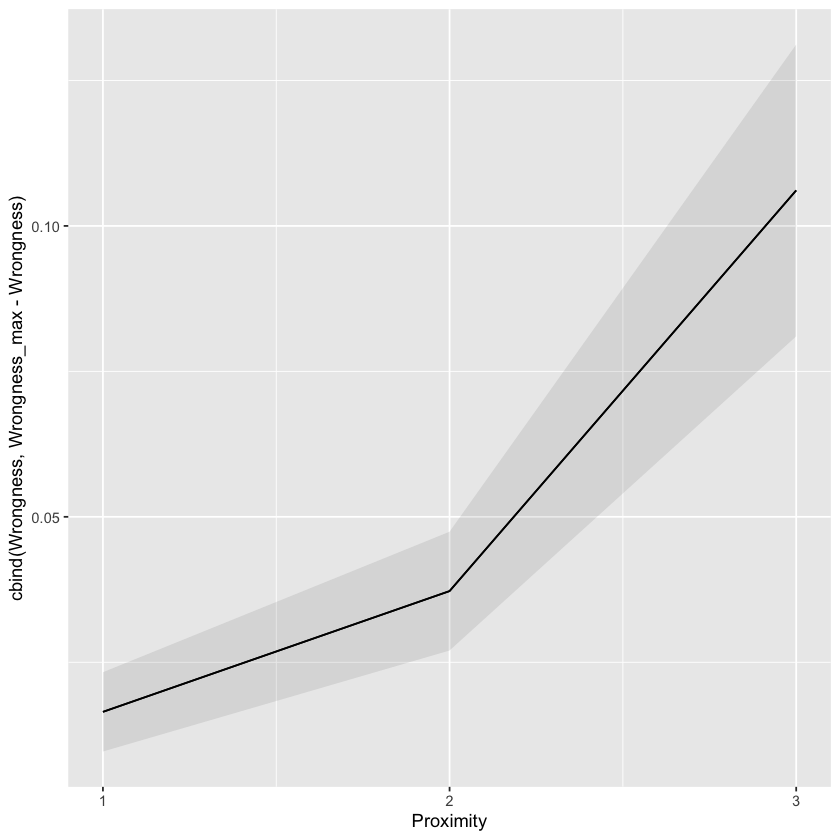

In [61]:
plot_predictions(model, by = c("Proximity")) +
    scale_x_continuous(breaks = c(1, 2, 3))

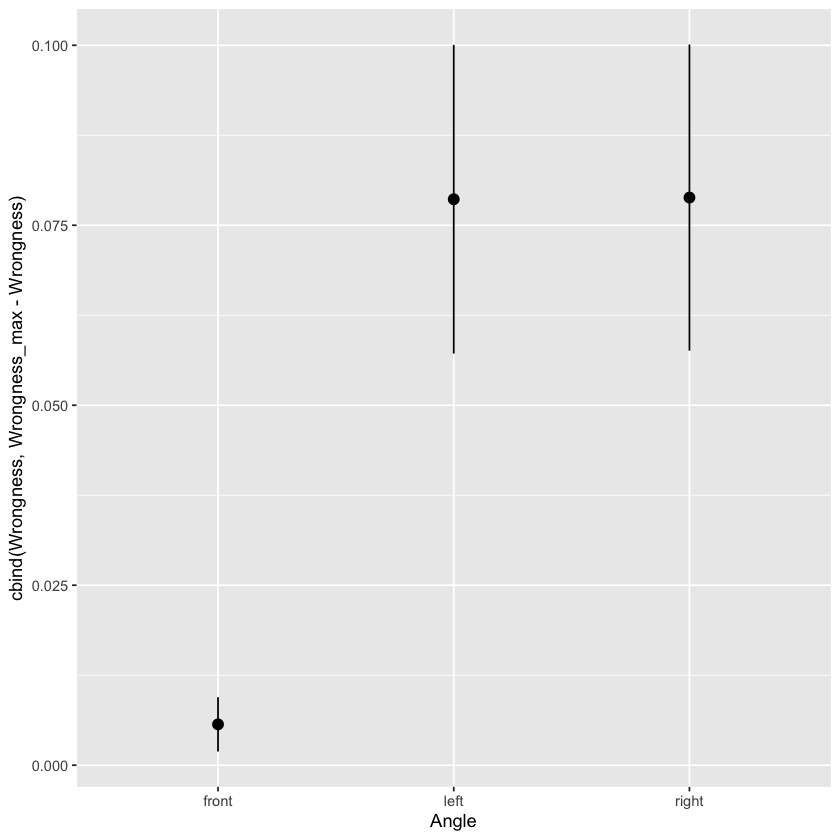

In [62]:
plot_predictions(model, by = c("Angle"))

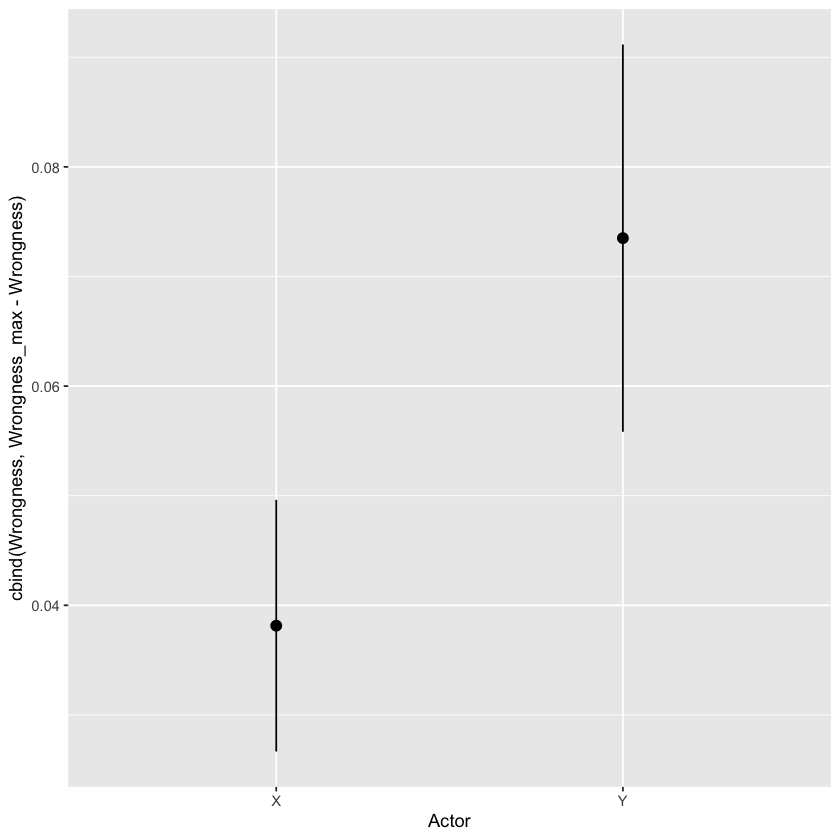

In [63]:
plot_predictions(model, by = c("Actor"))

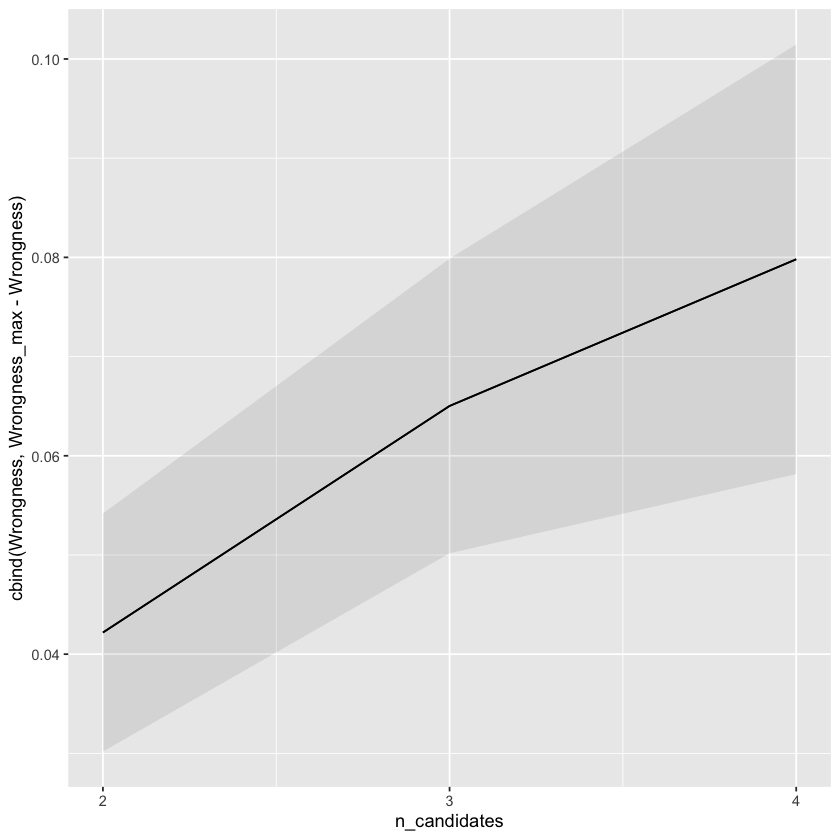

In [64]:
plot_predictions(model, by = c("n_candidates"))+ 
    scale_x_continuous(breaks = c(2, 3, 4))

In [65]:
avg_slopes(model, variables = "Proximity_c")
avg_slopes(model, variables = "n_candidates_c")
avg_comparisons(model, variables = "Angle")
avg_comparisons(model, variables = "Actor")

term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity_c,dY/dX,0.05501895,0.00815044,6.750427,1.474108e-11,35.98137,0.03904438,0.07099351,0.002652269,0.002652124,0.002652196


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates_c,dY/dX,0.01248434,0.005104882,2.44557,0.01446236,6.111554,0.002478959,0.02248973,0.002652112,0.002652281,0.002652196


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Angle,left - front,0.0691241,0.01012835,6.824817,8.803760e-12,36.72502,0.04927291,0.08897530
Angle,right - front,0.0727384,0.01078999,6.741285,1.569919e-11,35.89052,0.05159041,0.09388639


term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actor,Y - X,0.03384952,0.008319521,4.068687,4.72789e-05,14.36844,0.01754356,0.05015548,0.001237477,0.002652196,0.002652196


Conclusion: Proximity, View and Choice effect. Actor difference.

# Interpret interactions

In [66]:
model_null <- glmer(cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c + Angle + n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID), data = df, family = binomial, control = strict_control)
anova(model_null, model)

,npar,AIC,BIC,logLik,deviance,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_null,7,1421.429,1463.296,-703.7143,1407.429,NA,NA,NA
model,15,1394.299,1484.014,-682.1493,1364.299,43.13012,8,8.30231e-07


We find interactions! Now we need to unpack them.

### Proximity effect

In [67]:
avg_slopes(model, variables = "Proximity_c", by = "Angle")
avg_slopes(model, variables = "Proximity_c", by = "Angle", hypothesis = ~ pairwise)

term,contrast,Angle,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Proximity_c,dY/dX,front,0.003244519,0.002905127,1.116825,2.640691e-01,1.921012,-0.002449426,0.008938464
Proximity_c,dY/dX,left,0.080055946,0.017077572,4.687783,2.761811e-06,18.465954,0.046584520,0.113527372
Proximity_c,dY/dX,right,0.083249773,0.016368232,5.086058,3.655826e-07,21.383299,0.051168628,0.115330917


hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(left) - (front),0.076811427,0.01722265,4.4599075,8.199503e-06,16.8960321,0.04305565,0.11056720
(right) - (front),0.080005254,0.01654827,4.8346586,1.333743e-06,19.5160876,0.04757123,0.11243927
(right) - (left),0.003193827,0.02293338,0.1392654,8.892404e-01,0.1693545,-0.04175478,0.04814243


### Choice effect

In [68]:
avg_slopes(model, variables = "n_candidates_c", by = "Proximity")

term,contrast,Proximity,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
n_candidates_c,dY/dX,1,0.020047460,0.005467724,3.6665090,2.458842e-04,11.9897332,0.009330918,0.03076400
n_candidates_c,dY/dX,2,0.022344003,0.004257624,5.2479985,1.537606e-07,22.6328112,0.013999214,0.03068879
n_candidates_c,dY/dX,3,-0.004450049,0.011642743,-0.3822166,7.023007e-01,0.5098392,-0.027269406,0.01836931


In [69]:
avg_slopes(model, variables = "n_candidates_c", by = "Proximity", hypothesis = ~ pairwise)

hypothesis,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(2) - (1),0.002296543,0.003608257,0.6364689,0.52447085,0.9310655,-0.00477551,0.009368596
(3) - (1),-0.024497509,0.013816580,-1.7730516,0.07622016,3.7136836,-0.05157751,0.002582490
(3) - (2),-0.026794052,0.010815439,-2.4773891,0.01323475,6.2395250,-0.04799192,-0.005596180


### View effect

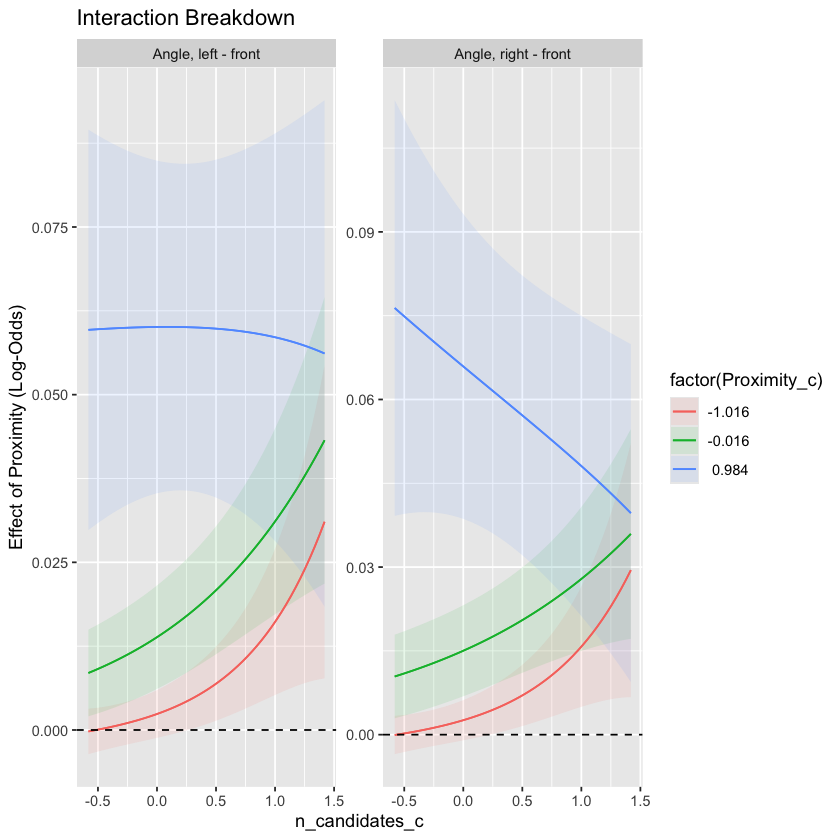

In [15]:
plot_slopes(
  model,
  variables = "Angle",
  condition = c("n_candidates_c", "Proximity_c") 
) +
  geom_hline(yintercept = 0, linetype = "dashed") + # Adds a line at 0 (null effect)
  labs(y = "Effect of Proximity (Log-Odds)", title = "Interaction Breakdown")

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.



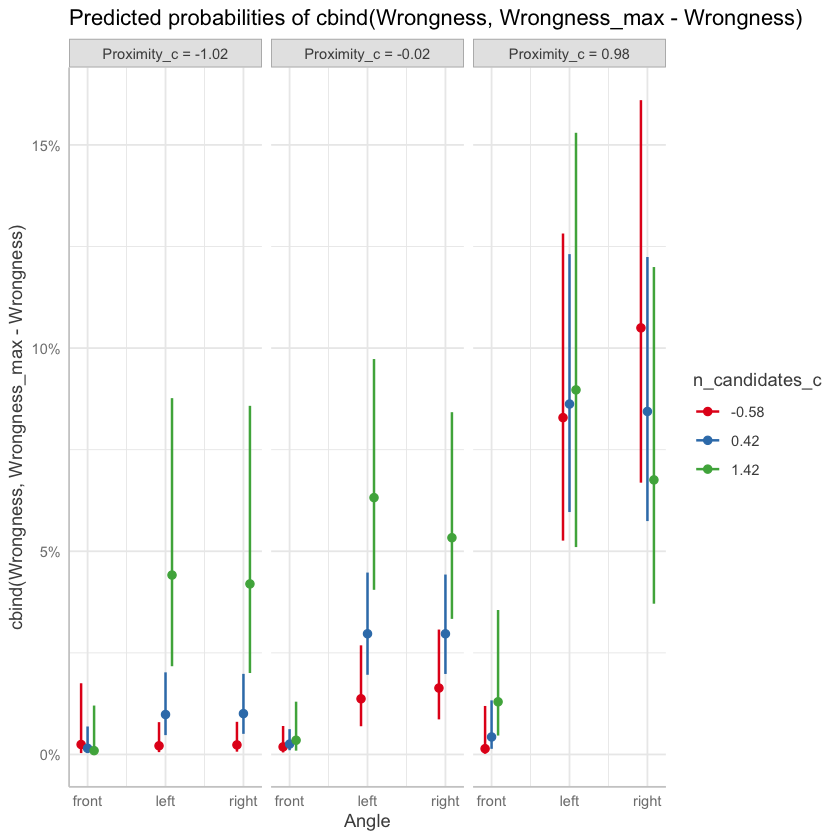

In [19]:

plot_model <- ggpredict(
  model, 
  terms = c("Angle [all]", "n_candidates_c [all]", "Proximity_c [all]")
)

plot(plot_model)

# Report

In [70]:
summary(model)


Correlation matrix not shown by default, as p = 13 > 12.
Use print(obj, correlation=TRUE)  or
    vcov(obj)        if you need it




Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: cbind(Wrongness, Wrongness_max - Wrongness) ~ Proximity_c * Angle *  
    n_candidates_c + Actor + offset(offset_logit) + (1 | Stimulus_ID) +  
    (1 | Participant_ID)
   Data: df
Control: strict_control

     AIC      BIC   logLik deviance df.resid 
  1394.3   1484.0   -682.1   1364.3     2910 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.1884 -0.2552 -0.0995 -0.0504 14.4228 

Random effects:
 Groups         Name        Variance Std.Dev.
 Stimulus_ID    (Intercept) 0.9035   0.9505  
 Participant_ID (Intercept) 0.2341   0.4839  
Number of obs: 2925, groups:  Stimulus_ID, 900; Participant_ID, 65

Fixed effects:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                            -6.1314     0.4534 -13.524  < 2e-16 ***
Proximity_c                             0.1889     0.4995   0.378  0.705

In [71]:
model_parameters(model)

Parameter,Coefficient,SE,CI,CI_low,CI_high,z,df_error,p,Effects,Group
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
(Intercept),-6.1314370,0.4533615,0.95,-7.0200092,-5.2428647,-13.5243884,Inf,1.122735e-41,fixed,
Proximity_c,0.1888664,0.4994635,0.95,-0.7900641,1.1677968,0.3781385,Inf,7.053277e-01,fixed,
Angleleft,2.3066814,0.4629669,0.95,1.3992828,3.2140799,4.9823888,Inf,6.280407e-07,fixed,
Angleright,2.3821130,0.4570455,0.95,1.4863204,3.2779057,5.2119825,Inf,1.868332e-07,fixed,
n_candidates_c,0.3311908,0.4241360,0.95,-0.5001006,1.1624822,0.7808598,Inf,4.348849e-01,fixed,
ActorY,0.7637311,0.1797629,0.95,0.4114023,1.1160598,4.2485470,Inf,2.151615e-05,fixed,
Proximity_c:Angleleft,1.2508352,0.5552563,0.95,0.1625529,2.3391176,2.2527168,Inf,2.427701e-02,fixed,
Proximity_c:Angleright,1.2716509,0.5523179,0.95,0.1891276,2.3541742,2.3023893,Inf,2.131323e-02,fixed,
Proximity_c:n_candidates_c,0.7960252,0.4993995,0.95,-0.1827799,1.7748303,1.5939646,Inf,1.109440e-01,fixed,


In [72]:
Anova(model, type = 3)

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),182.9090812,1,1.122735e-41
Proximity_c,0.1429887,1,7.053277e-01
Angle,28.8363428,2,5.473533e-07
n_candidates_c,0.6097421,1,4.348849e-01
Actor,18.0501516,1,2.151615e-05
Proximity_c:Angle,5.7070571,2,5.764057e-02
Proximity_c:n_candidates_c,2.5407231,1,1.109440e-01
Angle:n_candidates_c,1.0981984,2,5.774698e-01
Proximity_c:Angle:n_candidates_c,9.3966465,2,9.110540e-03


In [73]:
vc_list <- lapply(VarCorr(model), function(x) attr(x, "stddev")^2)
vc <- sum(unlist(vc_list))
effect_size_denom_t <- sqrt(vc + pi^2/3)

res <- summary(model)$coefficients
res <- as.data.frame(res)
res <- cbind(term = rownames(res), res)
rownames(res) <- NULL
res$`Pr(>|z|)` <- format(res$`Pr(>|z|)`, scientific = FALSE)
res$CI_low <- res$Estimate - 1.96 * res$`Std. Error`
res$CI_high <- res$Estimate + 1.96 * res$`Std. Error`
res$effect_size_denom <- effect_size_denom_t
res$effect_size <- res$Estimate / effect_size_denom_t
res

term,Estimate,Std. Error,z value,Pr(>|z|),CI_low,CI_high,effect_size_denom,effect_size
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-6.1314370,0.4533615,-13.5243884,0.00000000000000000000000000000000000000001122735,-7.0200255,-5.2428484,2.104167,-2.91395040
Proximity_c,0.1888664,0.4994635,0.3781385,0.70532771462455579047912124224239960312843322754,-0.7900821,1.1678148,2.104167,0.08975828
Angleleft,2.3066814,0.4629669,4.9823888,0.00000062804069849644632314800358000028701610518,1.3992661,3.2140966,2.104167,1.09624467
Angleright,2.3821130,0.4570455,5.2119825,0.00000018683317348472501502041926303016028398929,1.4863039,3.2779222,2.104167,1.13209339
n_candidates_c,0.3311908,0.4241360,0.7808598,0.43488494303231833848499832129164133220911026001,-0.5001158,1.1624974,2.104167,0.15739762
ActorY,0.7637311,0.1797629,4.2485470,0.00002151615097704942042777451205459726679691812,0.4113958,1.1160663,2.104167,0.36296132
Proximity_c:Angleleft,1.2508352,0.5552563,2.2527168,0.02427700824768653023455478034975385526195168495,0.1625329,2.3391376,2.104167,0.59445639
Proximity_c:Angleright,1.2716509,0.5523179,2.3023893,0.02131322870245729722560312779933155979961156845,0.1891077,2.3541941,2.104167,0.60434898
Proximity_c:n_candidates_c,0.7960252,0.4993995,1.5939646,0.11094396659781871616878845543396892026066780090,-0.1827979,1.7748482,2.104167,0.37830901


The below code is for generating the table in the paper.

In [74]:
stim_id_var_val <- if (!is.null(vc_list$Stimulus_ID) && length(vc_list$Stimulus_ID) > 0) vc_list$Stimulus_ID[[1]] else NA_real_
prompt_id_var_val <- if (!is.null(vc_list$Prompt_ID) && length(vc_list$Prompt_ID) > 0) vc_list$Prompt_ID[[1]] else NA_real_
participant_id_var_val <- if (!is.null(vc_list$Participant_ID) && length(vc_list$Participant_ID) > 0) vc_list$Participant_ID[[1]] else NA_real_

intercept_est <- res[res$term == "(Intercept)", "Estimate"]
intercept_se <- res[res$term == "(Intercept)", "Std. Error"]

angleleft_est <- res[res$term == "Angleleft", "Estimate"]
angleleft_se <- res[res$term == "Angleleft", "Std. Error"]
angleleft_p_val <- res[res$term == "Angleleft", "Pr(>|z|)"]
angleleft_eff_size <- res[res$term == "Angleleft", "effect_size"]

angleright_est <- res[res$term == "Angleright", "Estimate"]
angleright_se <- res[res$term == "Angleright", "Std. Error"]
angleright_p_val <- res[res$term == "Angleright", "Pr(>|z|)"]
angleright_eff_size <- res[res$term == "Angleright", "effect_size"]

proximity_term_name <- "scale(Proximity, scale = FALSE)"
if (!proximity_term_name %in% res$term) {
    proximity_term_name <- grep("Proximity", res$term, value = TRUE)[1]
}
proximity_est <- res[res$term == proximity_term_name, "Estimate"]
proximity_se <- res[res$term == proximity_term_name, "Std. Error"]
proximity_p_val <- res[res$term == proximity_term_name, "Pr(>|z|)"]
proximity_eff_size <- res[res$term == proximity_term_name, "effect_size"]

n_candidates_term_name <- "scale(n_candidates, scale = FALSE)"
if (!n_candidates_term_name %in% res$term) {
    n_candidates_term_name <- grep("n_candidates", res$term, value = TRUE)[1]
}
n_obj_est <- res[res$term == n_candidates_term_name, "Estimate"]
n_obj_se <- res[res$term == n_candidates_term_name, "Std. Error"]
n_obj_p_val <- res[res$term == n_candidates_term_name, "Pr(>|z|)"]
n_obj_eff_size <- res[res$term == n_candidates_term_name, "effect_size"]

actory_term_name <- "ActorY" # Assuming 'X' is the reference level for Actor factor
actory_est <- res[res$term == actory_term_name, "Estimate"]
actory_se <- res[res$term == actory_term_name, "Std. Error"]
actory_p_val <- res[res$term == actory_term_name, "Pr(>|z|)"]
actory_eff_size <- res[res$term == actory_term_name, "effect_size"]

# Prepare data for data frame
table_data <- list(
    c("StimulusID", "Variance", sprintf("%.7f", stim_id_var_val)),
    c("ParticipantID", "Variance", sprintf("%.7f", participant_id_var_val)),
    c("PromptID", "Variance", sprintf("%.7f", prompt_id_var_val)),
    c("Effect Size Denom", "", sprintf("%.7f", effect_size_denom_t)),

    c("Intercept", "b", sprintf("%.7f", intercept_est)),
    c("", "SE", sprintf("%.7f", intercept_se)),

    c("Angleleft", "b", sprintf("%.7f", angleleft_est)),
    c("", "SE", sprintf("%.7f", angleleft_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleleft_p_val))),
    c("", "Effect size", sprintf("%.7f", angleleft_eff_size)),

    c("Angleright", "b", sprintf("%.7f", angleright_est)),
    c("", "SE", sprintf("%.7f", angleright_se)),
    c("", "p", sprintf("%.7f", as.numeric(angleright_p_val))),
    c("", "Effect size", sprintf("%.7f", angleright_eff_size)),

    c("Proximity", "b", sprintf("%.7f", proximity_est)),
    c("", "SE", sprintf("%.7f", proximity_se)),
    c("", "p", sprintf("%.7f", as.numeric(proximity_p_val))),
    c("", "Effect size", sprintf("%.7f", proximity_eff_size)),

    c("#Object", "b", sprintf("%.7f", n_obj_est)),
    c("", "SE", sprintf("%.7f", n_obj_se)),
    c("", "p", sprintf("%.7f", as.numeric(n_obj_p_val))),
    c("", "Effect size", sprintf("%.7f", n_obj_eff_size)),

    c("ActorY", "b", sprintf("%.7f", actory_est)),
    c("", "SE", sprintf("%.7f", actory_se)),
    c("", "p", sprintf("%.7f", as.numeric(actory_p_val))),
    c("", "Effect size", sprintf("%.7f", actory_eff_size))
)

# Convert to data frame
df_output <- do.call(rbind, lapply(table_data, function(x) data.frame(V1=x[1], V2=x[2], V3=x[3], stringsAsFactors=FALSE)))

# Print only the third column for easy copy-pasting to Excel
write.table(df_output[,3, drop=FALSE], file="", sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)

0.9035146
0.2341342
NA
2.1041665
-6.1314370
0.4533615
2.3066814
0.4629669
0.0000006
1.0962447
2.3821130
0.4570455
0.0000002
1.1320934
0.1888664
0.4994635
0.7053277
0.0897583
0.3311908
0.4241360
0.4348849
0.1573976
0.7637311
0.1797629
0.0000215
0.3629613
